## Example - minimizing path time across two terrains

This is the implementation from the presentation: we want to minimize the time from point A to point B when crossing terrains with different speeds.

![Terrain crossing problem](artifacts/example1/problem.png)

### Imports and constants

In [1]:
import torch
from utils.example import *

In [2]:
V1 = 10   # Speed on first terrain
V2 = 1.2  # Speed on second terrain
D1 = 15
D2 = 20
H = 18

### Time computation

This function accepts `x` and computes the corresponding path time. We use `torch.sqrt` so that the result can be differentiated automatically by PyTorch.

In [3]:
def calculate_time(x):
    y = H - x
    return torch.sqrt(x ** 2 + D1 ** 2) / V1 + torch.sqrt(D2 ** 2 + y ** 2) / V2

### Gradient descent
We use PyTorch to implement gradient descent on the time function. A few things to notice:

* Initialization - choice of where to start, `requires_grad=True`
* Optimizer (`SGD` - "stochastic gradient descent") accepts list of parameters to optimize
* Choice of gradient step size (`lr`)
* Zero-ing gradients before stepping

We also use helper functions to log the history of the optimization and visualize it.

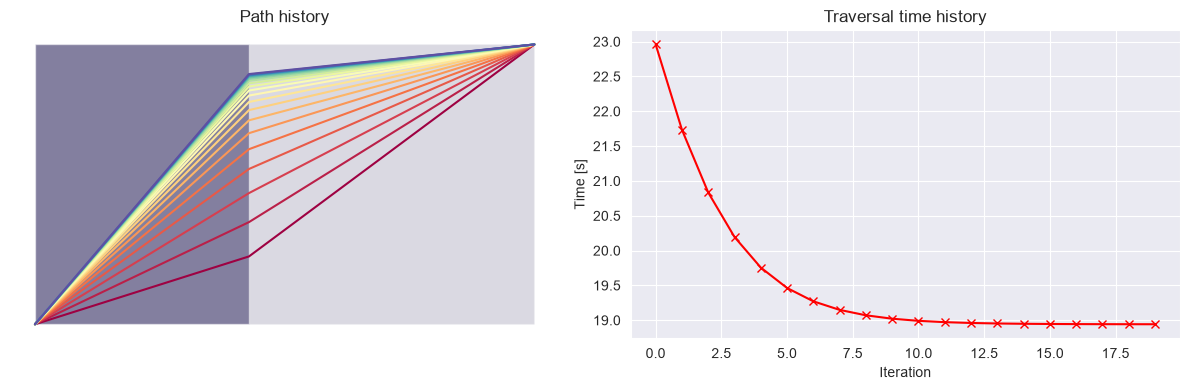

In [4]:
x = torch.tensor(.1 * 18, requires_grad=True)
optimizer = torch.optim.SGD([x], lr=5)

reset_history()
for i in range(20):
    time = calculate_time(x)
    
    optimizer.zero_grad()
    time.backward()
    optimizer.step()

    log_history(x, time)

visualize_history()

### Food for thought

Play with the following hyper-parameters and examine how they affect the optimization:
* Gradient step size (`lr`)
* Initialization
* Number of iterations